In [6]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np
from pybaselines import Baseline, utils
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter # Savitzky-Golay filter
import os 
import glob
from galvani import BioLogic as BL
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio # For Plotly themes 
from datetime import datetime, timedelta
import imageio
import h5py

In [3]:
plt.rcParams['font.family'] = 'Arial' 

# Function for reading files

In [4]:
# Read HDF5 Data Function with Electrochemical Data (optional)
def read_hdf5_data(hdf5_file_path):
    with h5py.File(hdf5_file_path, 'r') as hdf5_file:
        saxs_data = {}
        waxs_data = {}
        time_stamp_saxs = {}
        time_stamp_waxs = {}
        electrochemical_data = {}  # For electrochemical data

        # Reading SAXS data
        if 'SAXS' in hdf5_file:
            for key in hdf5_file['SAXS'].keys():
                saxs_data[key] = pd.DataFrame(hdf5_file['SAXS'][key][:])
                time_stamp_saxs[key] = hdf5_file['SAXS'][key].attrs['timestamp']

        # Reading WAXS data
        if 'WAXS' in hdf5_file:
            for key in hdf5_file['WAXS'].keys():
                waxs_data[key] = pd.DataFrame(hdf5_file['WAXS'][key][:])
                time_stamp_waxs[key] = hdf5_file['WAXS'][key].attrs['timestamp']

        # Check if electrochemical data is available and read only the "data" part
        if 'ElectrochemicalData' in hdf5_file:
            if 'data' in hdf5_file['ElectrochemicalData']:
                electrochemical_data = pd.DataFrame(hdf5_file['ElectrochemicalData']['data'][:])

        if 'Backgrounds' in hdf5_file:
            if 'SAXS' in hdf5_file['Backgrounds']:
                for key in hdf5_file['Backgrounds']['SAXS'].keys():
                    SAXS_background = pd.DataFrame(hdf5_file['Backgrounds']['SAXS'][key][:])

        if 'Backgrounds' in hdf5_file:
            if 'WAXS' in hdf5_file['Backgrounds']:
                for key in hdf5_file['Backgrounds']['WAXS'].keys():
                    WAXS_background = pd.DataFrame(hdf5_file['Backgrounds']['WAXS'][key][:])

        return saxs_data, time_stamp_saxs, waxs_data, time_stamp_waxs, electrochemical_data,SAXS_background, WAXS_background


In [7]:
hdf5_file_path = r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240820_2503SKJB_satDME_200HFE_120uL_1G1PS\cycle\20240820_satDME.h5'
saxs_data, time_stamp_saxs, waxs_data, time_stamp_waxs, elec_df_temp, SAXS_background, WAXS_background = read_hdf5_data(hdf5_file_path)

# Example: Print the number of SAXS and WAXS files
print(f"Number of SAXS files: {len(saxs_data)}")
print(f"Number of WAXS files: {len(waxs_data)}")

Number of SAXS files: 1254
Number of WAXS files: 1254


# Function for finding timestamps

In [8]:
def find_nearest_time(target_time, time_dict):
    new_time_dict = {}
    keys = list(time_dict.keys())
    base_time = datetime.strptime(time_dict[keys[0]], '%Y-%m-%dT%H:%M:%S')
    count = 0
    for entry in time_dict:
        current_time = datetime.strptime(time_dict[entry], '%Y-%m-%dT%H:%M:%S')
        time_difference = (current_time - base_time).total_seconds()
        new_time_dict[time_difference] = count
        count += 1
    nearest_time_difference = min(new_time_dict, key=lambda x: abs(x - target_time))
    nearest_key = new_time_dict[nearest_time_difference]
    return nearest_key, new_time_dict


# Fitting Functions

In [9]:
def lorentzian(x, a, x0, w0):
    return a* w0**2 / (w0**2 + (x - x0)**2)

def multi_lorentzian(x, *params):
    num_peaks = (len(params) - 1) // 3  
    baseline = params[-1]
    y = np.zeros_like(x) + baseline
    for j in range(num_peaks):
        a = params[3 * j]
        x0 = params[3 * j + 1]  
        w0 = params[3 * j + 2]
        y += lorentzian(x, a, x0, w0)
    return y

def lorentzian2(x, *params):
    a = params[0]
    x0 = params[1]  
    w0 = params[2]
    baseline = params[-1]
    return a* w0**2 / (w0**2 + (x - x0)**2) + baseline

In [10]:
def smooth_data(data, window_length=10, polyorder=3):
    return savgol_filter(data, window_length, polyorder)

# Contourplot

In [11]:
# Function contour plots 
def contourplot(plot_type, data_normalization, data_dictionary, new_time_dict, min_limit, max_limit, cmap_min = None, cmap_max = None):
    import matplotlib.ticker as mticker
    
    plt.style.use('default')
    keys = list(new_time_dict.keys())
    file_names = list(data_dictionary.keys())
    time_t1 = []
    Intensity_list = []
    print(starting_file,discharge_file, last_file)
    X1_data_temp = 10*data_dictionary[file_names[starting_file]].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 

    indices_within_range = np.where((X1_data_temp >= min_limit) & (X1_data_temp <= max_limit))
    #print("Positions where data is within the range:", indices_within_range)

    X1_data_filtered_positions = X1_data_temp.iloc[indices_within_range]
    #print("Values at positions within the range:", X1_data_filtered_positions)
    start_row = np.min(indices_within_range)
    end_row = np.max(indices_within_range)

    # print('valuesof rows', start_row, end_row)

    for file_number in range(starting_file, last_file+1):  
        if data_normalization == 'relative':
            Y1_data = [(data_dictionary[file_names[file_number]].iloc[start_row:end_row+1,1])/data_dictionary[file_names[discharge_file]].iloc[start_row:end_row+1,1]]
        else:
            Y1_data = [(data_dictionary[file_names[file_number]].iloc[start_row:end_row+1,1])]
        time_t1.append(int(keys[file_number-1]-keys[starting_file-1]))   # The '-1' is because the time keys actually start from 0 whereas the file numbers start from 1.     
        Intensity_list.append(list(Y1_data))   

    #print(norm_intensity)
    normIntensity_array = np.array(Intensity_list)
    #print(normIntensity_array)
    X, Y = np.meshgrid(X1_data_filtered_positions, time_t1)
    normIntensity_flat = normIntensity_array[:, 0, :]

    cmap1 = plt.colormaps.get_cmap('viridis')  

    # data for the charge-discharge plot
    relative_time = (elec_df_2[2] - elec_df_2[2].iloc[0])
    # Finding minimum and maximum times to limit the axs from having automatic margins in subplot
    min_time = relative_time.min()
    max_time = relative_time.max()

    fig, axs = plt.subplots(1,2, figsize = (8,5), sharey = True, gridspec_kw = {'width_ratios': [1,4]})
    axs[0].plot(elec_df_2[6], relative_time,  color = 'r')

    # plot1.set_xlabel('Time(s)')
    axs[0].invert_xaxis()
    axs[0].set_ylabel('Time (s)')
    axs[0].set_xlabel('Potential (V)')
    axs[0].set_ylim(min_time, max_time)

    contour = axs[1].contourf(X, Y,normIntensity_flat, cmap = cmap1, vmin=cmap_min, vmax=cmap_max)
    
    if data_normalization == 'relative':
        cbar = fig.colorbar(contour, ax = axs[1], label = 'Ralative intensity (a.u.)')
    else:
        cbar = fig.colorbar(contour, ax = axs[1], label = 'Intensity (a.u.)')

    
    # Adjust the space between the two subplots
    fig.subplots_adjust(wspace = 0)
    axs[1].set_xlabel('q (nm $^{-1}$)')
    if plot_type == 'saxs':
        axs[1].set_xscale('log')
        axs[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
        axs[1].xaxis.set_minor_formatter(mticker.ScalarFormatter())
        

        # Define custom ticks and labels
        ticks = np.arange(min_limit, max_limit, 0.5)
        tick_labels = [f'{tick:.1f}' for tick in ticks]

        axs[1].set_xticks(ticks)
        axs[1].set_xticklabels(tick_labels)
        axs[1].xaxis.set_minor_locator(mticker.NullLocator())  # Remove minor ticks
    
    return

# Read all the files

In [153]:
'''# os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240816_2503SKJB_satDME_200HFE_120uL_1G1PS\test')
# mpr = BL.MPRfile(r'./20240816_2503SKJB_0pt9mg_satDME_200HFE_120uL_1G1PS_C02.mpr')

# os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240812_2503SKJB_6MECDEC-200HFE_120uL_1G1PS\cycle')
# mpr = BL.MPRfile(r'./20240812_2503-SKJB_1pt1mg_6MECDEC_200HFE_120uL_1G1PS_C02.mpr')         

# os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240814_2503SKJB_1MLiTFSI_DOLDME_120uL_1G1PS\cycle')
# mpr = BL.MPRfile(r'./20240814_2503-SKJB_1mg_1MLiTFSI_DOLDME_0pt1-LiNO3_120uL_1G1PS_C02.mpr')

# sat DME with 200 HFE, 2 seperator (1G1PS) with 120 uL electrolyte (2nd iter)
# os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240820_2503SKJB_satDME_200HFE_120uL_1G1PS\cycle')
# mpr = BL.MPRfile(r'./20240820_2503SKJB_1pt12mg_satDME_200HFE_120uL_1G1PS_C02.mpr')

# os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240808_2503-SKJB_1MLITFSI-DOLDME_50uL_1G1PS\cycle')
# mpr = BL.MPRfile(r'./20240808_2503-SKJB_1mg_1MLiTFSI_DOLDME_0pt1LiNO3_50uL_1G1PS_C02.mpr')

os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240828_2503SKJB_6MECDEC-200HFE_120uL_1G1PS\cycle')
mpr = BL.MPRfile(r'./20240828_2503-SKJB_1mg_6MECDEC_200HFE_120uL_1G1PS_C02.mpr')

file_list = glob.glob('*_1_*.dat')

legend = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp = {} #Dictionary to store the time of file creation
key = 0
file_dictionary = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list:
    key += 1
    legend[key], time_stamp[key], file_dictionary[key] = read_data(data_file)

    
print('Number of files:',key)'''

Number of files: 863


# Read EC lab files 

Indices for cycle change [961, 7817, 14451, 21011, 27399, 33569, 39670, 45435, 51095, 51905, 51907]

Absolute times for change in electrochemical state: 
[960.00037574835, 35227.318953969865, 68386.7453360986, 101173.79378058692, 133100.59562584397, 163939.07145088539, 194431.8802218414, 223243.98032983532, 251529.01835535956, 255568.09218732174, 255568.0933873218]


Text(0, 0.5, 'Potential (V)')

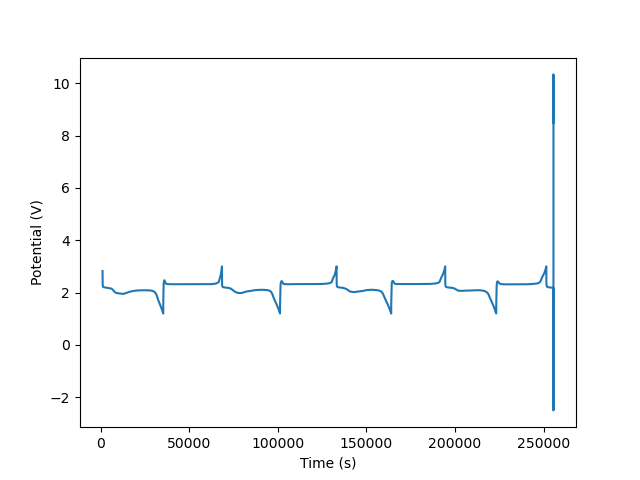

In [14]:
plt.figure()

filter = elec_df_temp[1] != 0
elec_df = elec_df_temp[filter]

    # Track the diffent times for charge-discharge by noting when the Ns value changes

cycle_change_index = []
absolute_times_for_electrochemical_state_change = []

# Add the very first values of the index and time 
cycle_change_index.append(elec_df.index[0])
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[0],2])

for line in range(len(elec_df[1])-1):
    if elec_df[1].iloc[line] != elec_df[1].iloc[line+1]:
        cycle_change_index.append(elec_df.index[line+1])
        absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 2])

cycle_change_index.append(elec_df.index[line+1]) #Takes the index for the last file also  
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 2])

print("Indices for cycle change", cycle_change_index)
print("\nAbsolute times for change in electrochemical state: ")
print(absolute_times_for_electrochemical_state_change)

# Plot the read electrochemical file
Elec_Xdata = elec_df[2]
Elec_Ydata = elec_df[6]
plt.plot(Elec_Xdata,Elec_Ydata)
plt.xlabel('Time (s)')
plt.ylabel('Potential (V)')

# Data Segregation

Total number of cycles: 5

Biologic data file line details:
Line numbers for each electrochemical change event : [961, 7817, 14451]
Corresponding times for each electrochemical change event:  ['960.00', '35227.32', '68386.75']
Files numbers for SAXS data [5, 174, 337]


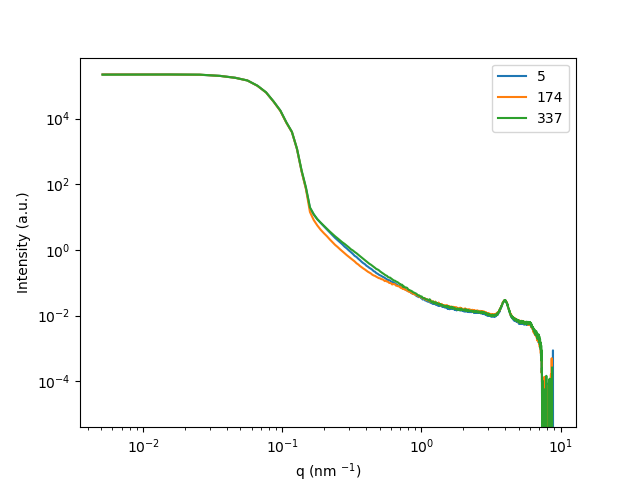

In [13]:
print('Total number of cycles:', len(cycle_change_index)//2)

# Filter the DataFrame by the condition
starting_cycle = int(input("Starting cycle to plot:"))
end_cycle = int(input("Final cycle to plot:"))
file_names = list(saxs_data.keys())

change_cycle_line = []
discharge_start_time = []
saxs_file_numbers = []

starting_index_for_EC_data = 2*starting_cycle-2
ending_index_for_EC_data = 2*end_cycle

print('\nBiologic data file line details:')
print('Line numbers for each electrochemical change event :',
       [cycle_change_index[_] for _ in range(starting_index_for_EC_data, ending_index_for_EC_data+1)])
print('Corresponding times for each electrochemical change event: ', 
      [f"{absolute_times_for_electrochemical_state_change[i]:.2f}" for i in range(2*starting_cycle-2, 2*end_cycle+1)])

# creates a new data frame for the plot
elec_df_2 = elec_df.iloc[cycle_change_index[starting_index_for_EC_data] - cycle_change_index[0] : 
                         cycle_change_index[ending_index_for_EC_data] - cycle_change_index[0]]
elec_df_2.to_csv('electrochem_datafile2.txt', sep = '\t')

plt.style.use('default')
plt.figure()

# find the corresponding starting abd ending SAXS file
for entry in range(starting_index_for_EC_data, ending_index_for_EC_data+1):
    saxs_file_index, new_time_dict  = find_nearest_time(absolute_times_for_electrochemical_state_change[entry], time_stamp_saxs)
    saxs_file_numbers.append(saxs_file_index)
    X1_data = 10*saxs_data[file_names[saxs_file_index]].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y1_data = saxs_data[file_names[saxs_file_index]].iloc[:,1]
    plt.plot(X1_data, Y1_data, label= saxs_file_index)
""" # Printing the file details for manual verification of file numbers   
    print(f"Starting SAXS file no.: {saxs_file_index}")
    print('Time stamps:')
    print(time_stamp[saxs_file_index])"""

starting_file = saxs_file_numbers[0]
discharge_file = saxs_file_numbers[1]
last_file = saxs_file_numbers[-1]
print("Files numbers for SAXS data",saxs_file_numbers)
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.xscale('log')
plt.yscale('log')

# For Baseline correction (manually select the first long exposure file)

filtered position: 220, 633, value: 13.98411125091297, 24.995432407494583


C:\Users\b1104371\AppData\Local\Temp\ipykernel_42576\1255451445.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


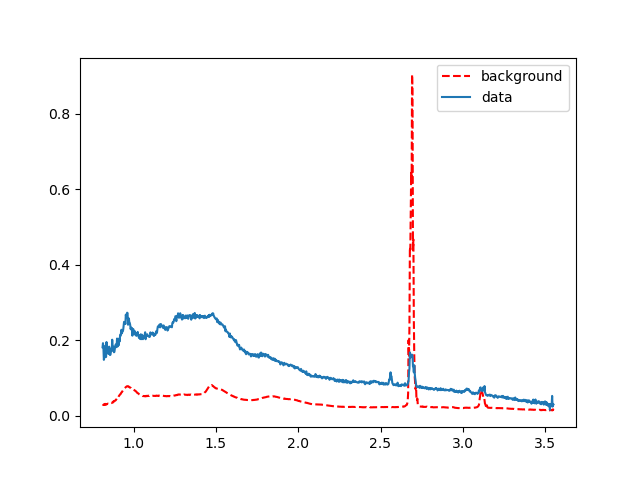

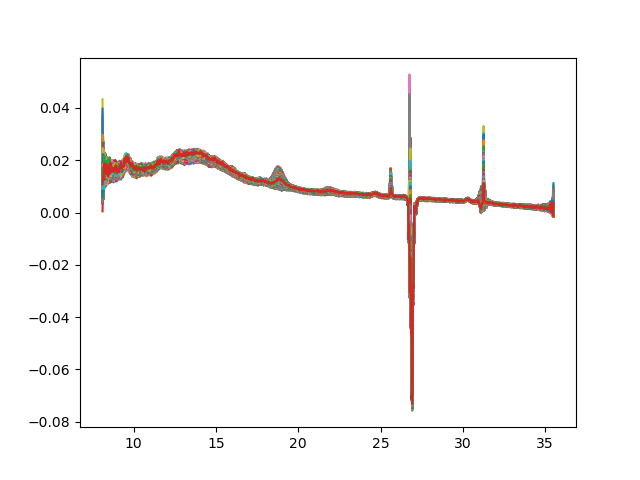

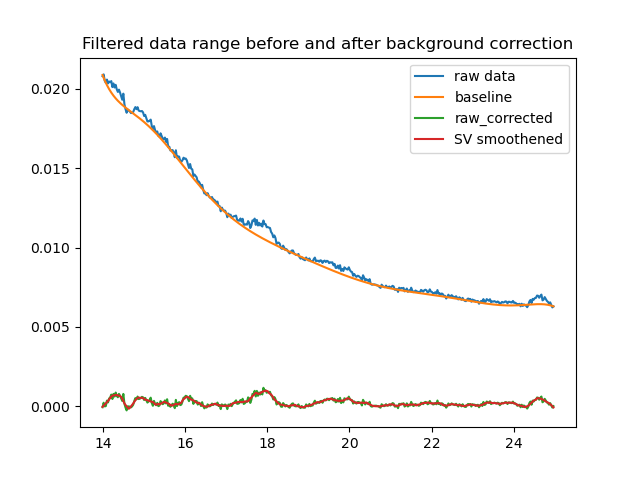

In [17]:
plt.figure()
waxs_file_names = list(waxs_data.keys())
# print(background.iloc[:,0])
plt.plot(WAXS_background.iloc[:,0], 10*WAXS_background.iloc[:,1], 'r--', label = 'background')
plt.plot(waxs_data[waxs_file_names[1]].iloc[:,0],10*waxs_data[waxs_file_names[1]].iloc[:,1], label = 'data')
plt.legend()
plt.figure()

empty_cell_corrected_waxs_files = {}

for ikey in waxs_data:
    X_data = 10*waxs_data[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = waxs_data[ikey].iloc[:,1]
    modified_Y = Y_data - 1* WAXS_background.iloc[:,1]
    plt.plot(X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    empty_cell_corrected_waxs_files[ikey] = df

#filter the range for the WAXS
filtered_X_range_min = np.max(np.where(X_data <= 14))
filtered_X_range_max = np.max(np.where(X_data <= 25))
# print(empty_cell_corrected_waxs_files)
print(f"filtered position: {filtered_X_range_min}, {filtered_X_range_max}, value: {X_data[filtered_X_range_min]}, {X_data[filtered_X_range_max]}")

                                  # Substract a polynomial over the empty cell corrected files #

# Create an average over the first four files for background generation
x_data = 0
y_data = 0
file_count = 0
for files in range(1,5):
    x_data += empty_cell_corrected_waxs_files[waxs_file_names[files]].iloc[filtered_X_range_min:filtered_X_range_max,0]
    y_data += empty_cell_corrected_waxs_files[waxs_file_names[files]].iloc[filtered_X_range_min:filtered_X_range_max,1]
    file_count += 1

# average over the summed data 
x_data = x_data/file_count
y_data = y_data/file_count

plt.figure()
plt.title("Filtered data range before and after background correction")
baseline_filter = Baseline(x_data = x_data)
baseline = baseline_filter.modpoly(y_data, poly_order= 10)[0]
# print(baseline)
modified_y = y_data-baseline
smoothed_Y = smooth_data(modified_y, window_length=11, polyorder=2)

plt.plot(x_data, y_data, label = 'raw data')
plt.plot(x_data, baseline, label = 'baseline')
plt.plot(x_data, modified_y, label = 'raw_corrected')
plt.plot(x_data, smoothed_Y, label = 'SV smoothened')
plt.legend()


# Create new file dictionary with corrected spectra
corrected_waxs_files = {}

for ikey in empty_cell_corrected_waxs_files:
    min_val = 0
    max_val = 0
    modified_Y = 0
    X1_values = empty_cell_corrected_waxs_files[ikey].iloc[filtered_X_range_min:filtered_X_range_max,0] 
    Y1_values = empty_cell_corrected_waxs_files[ikey].iloc[filtered_X_range_min:filtered_X_range_max,1]
    
    # define baselines for individual files and subtract from the data
    baseline_filter = Baseline(x_data = X1_values)
    baseline = baseline_filter.modpoly(Y1_values, poly_order= 10)[0]
    modified_Y = Y1_values - baseline

    # Smooth the data
    smoothed_Y = smooth_data(modified_Y, window_length=11, polyorder=2)

    # min_val = np.min(smoothed_Y)
    # max_val = np.max(smoothed_Y)
    normalized_Y = smoothed_Y #'(smoothed_Y - min_val)/(max_val - min_val)' # Normalized the data between [0,1]
    df = pd.DataFrame({'X_data': X1_values, 'Modified_Y': modified_Y}) # change the 'Modified_Y' as per the requirement, raw, smoothened or smoothened plus normalized 
    corrected_waxs_files[ikey] = df

cmap = cm.get_cmap('viridis')  
num_files = len(corrected_waxs_files)
colors = [cmap(i / num_files) for i in range(num_files)]  # Generate colors


# 3D waterfall plot

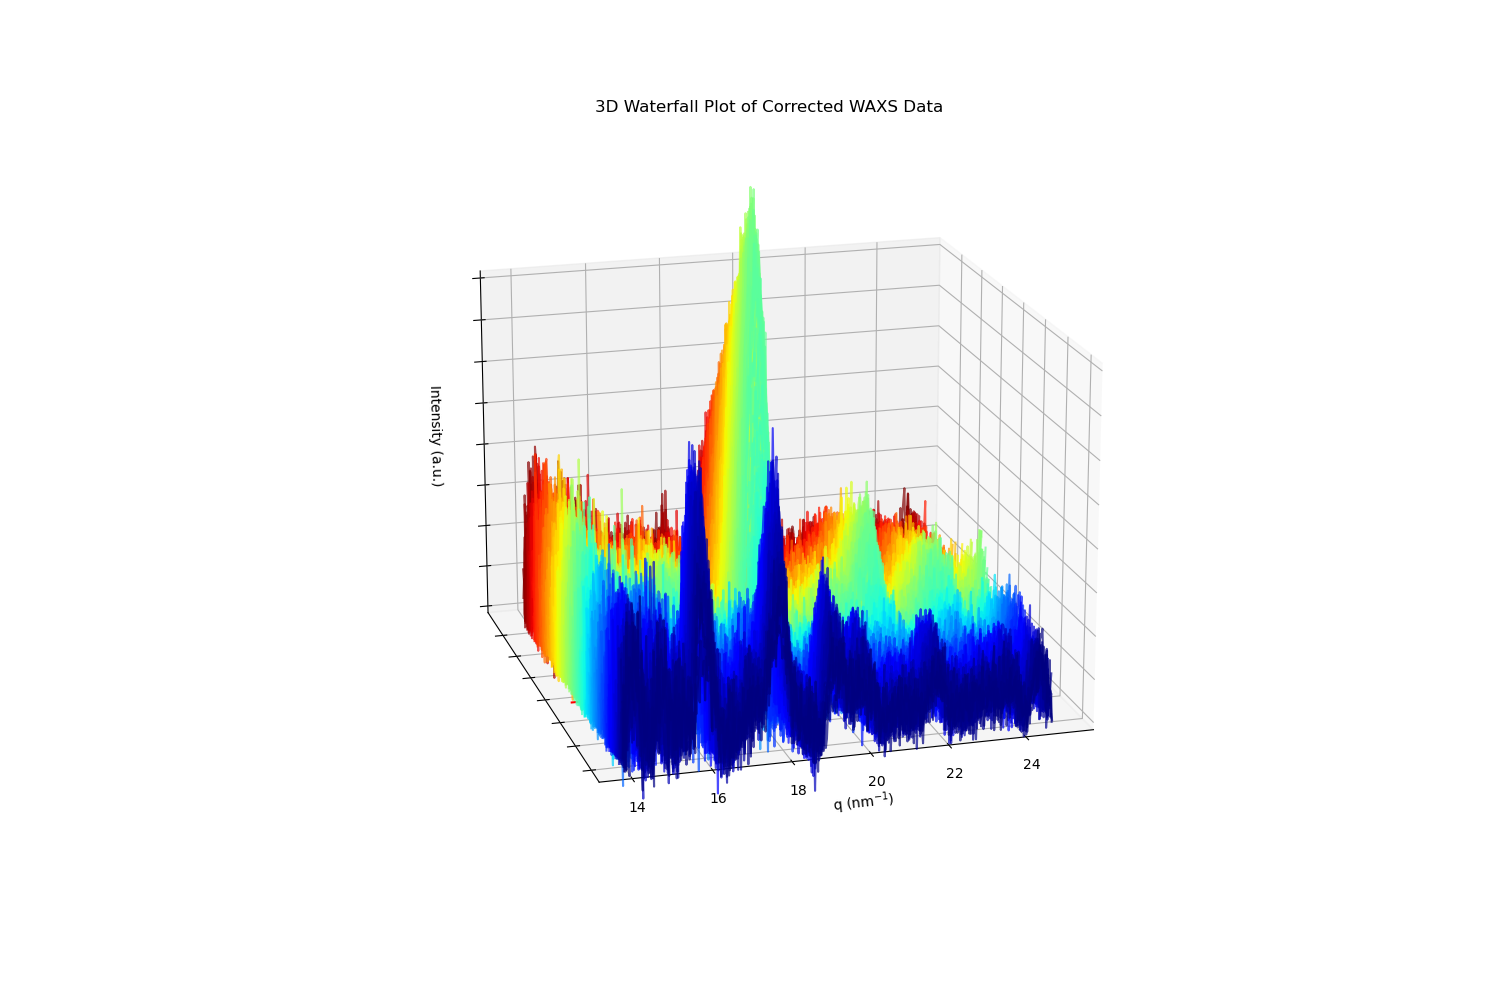

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Initialize the figure
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
plt.title("3D Waterfall Plot of Corrected WAXS Data")

# Base offset for the waterfall plot
base_offset = 0.0
offset_increment = 0.00001  # value to increase/decrease the spacing between curves

# Set the transparency level
transparency = 0.7  

# List of keys and reverse it
keys = list(range(starting_file, last_file + 1))
keys.reverse()  # Reverse the order

# Adjust the saxs_file_numbers list to exclude the first and last entries
adjusted_saxs_file_numbers = saxs_file_numbers[1:-1]  # Exclude first and last entries

for ikey in keys:
    # Extract the X and Y values
    X1_values = corrected_waxs_files[waxs_file_names[ikey]].iloc[:, 0] 
    modified_Y = corrected_waxs_files[waxs_file_names[ikey]].iloc[:, 1]  
    
    # Apply vertical offset for the Z axis (used for time or series offset)
    offset = base_offset + (ikey - starting_file) * offset_increment
    Z = np.full_like(X1_values, offset)  # Constant Z value for this curve
    
    # Plot the curve in 3D with transparency
    ax.plot(X1_values, Z, modified_Y, color=cm.jet((ikey - starting_file) / (last_file - starting_file)), alpha=transparency)

    # Mark the z-axis if ikey is in the adjusted saxs_file_numbers
    if ikey in adjusted_saxs_file_numbers:
        ax.plot([X1_values.min(), X1_values.max()], [offset, offset], [modified_Y.min(), modified_Y.min()], 
                color='red', linestyle='--', linewidth=1.5, label=f"Marker for ikey {ikey}")

# Set axis labels
ax.set_xlabel('q (nm$^{-1}$)')
ax.set_ylabel('') 
ax.set_zlabel('Intensity (a.u.)')
ax.zaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

# Set limits and view angle
# ax.set_xlim(14, 25)
ax.set_zlim(0, 0.004)
ax.view_init(elev=18, azim=-106)  # elevation and azimuth to adjust the 3D view

# Show the plot with the marker
plt.show()


In [108]:
# Open a text file in write mode
with open('waxs_data.txt', 'w') as file:
    # Write header
    file.write("X1_value\t" + "\t".join([f"modified_Y_{ikey}" for ikey in corrected_waxs_files]) + "\n")
    
    # Extract the X1 values from the first file
    first_X1_values = corrected_waxs_files[list(corrected_waxs_files.keys())[0]].iloc[:, 0]
    
    # Loop over the X1 values (rows)
    for i in range(len(first_X1_values)):
        # Get the first X1_value from the first file
        x1_value = first_X1_values.iloc[i]
        
        # Collect corresponding modified_Y values from all files
        y_values = [corrected_waxs_files[ikey].iloc[i, 1] for ikey in corrected_waxs_files]
        
        # Write X1_value followed by all corresponding Y values
        file.write(f"{x1_value}\t" + "\t".join([str(y) for y in y_values]) + "\n")

print("Data written to waxs_data.txt")


Data written to waxs_data.txt


# Creating the Polynomial background (With a average over the first three files)

'plt.xlim(15,22)\nplt.ylim(-0.001,0.008)'

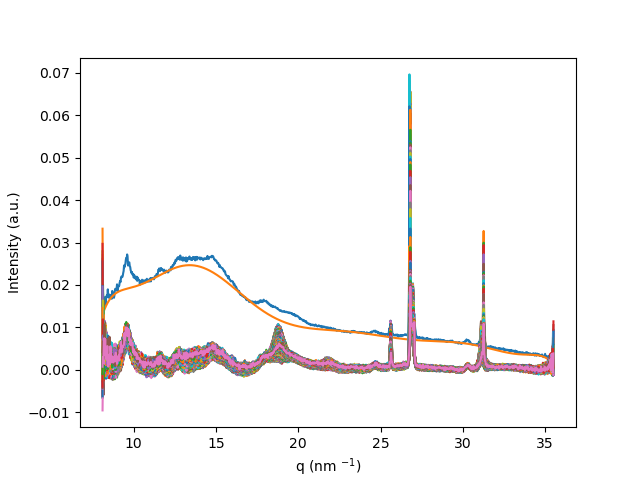

In [21]:
X_data = []
Y_data = []

# Create a average over the first three data files 
plt.figure()
for files in range(1,4):
    if files == 1:
        X_data = 10*waxs_data[waxs_file_names[files]].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data = waxs_data[waxs_file_names[files]].iloc[:,1]
        # print(X_data)
    else:
        X_data += 10*waxs_data[waxs_file_names[files]].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data += waxs_data[waxs_file_names[files]].iloc[:,1]

for entries in range(len(X_data)):
    X_data[entries] = X_data[entries]/3
    Y_data[entries] = Y_data[entries]/3

baseline_filter = Baseline(x_data = X_data)
baseline = baseline_filter.modpoly(Y_data, poly_order= 10)[0]
# print(baseline)
modified_Y = Y_data-baseline
plt.plot(X_data, Y_data)
plt.plot(X_data, baseline)
plt.plot(X_data, modified_Y)

# Create new file dictionary with corrected spectra
corrected_waxs_files = {}
for ikey in waxs_data:
    X_data = 10*waxs_data[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = waxs_data[ikey].iloc[:,1]
    modified_Y = Y_data - baseline
    plt.plot(X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
"""plt.xlim(15,22)
plt.ylim(-0.001,0.008)"""

# Check the plot for determination of two-theta and no of peaks for fitting 

Peak 1:
 Amplitude = 0.0016 +/- 0.0001
 Center = 15.70 +/- 0.0181
 Width = 0.2601 +/- 0.0393
 Area = 0.0022 
Peak 2:
 Amplitude = 0.0006 +/- 0.0002
 Center = 17.91 +/- 0.0437
 Width = 0.3138 +/- 0.0939
 Area = 0.0016 
Peak 3:
 Amplitude = 0.0044 +/- 0.0001
 Center = 18.83 +/- 0.0222
 Width = 0.6884 +/- 0.0501
 Area = 0.0119 


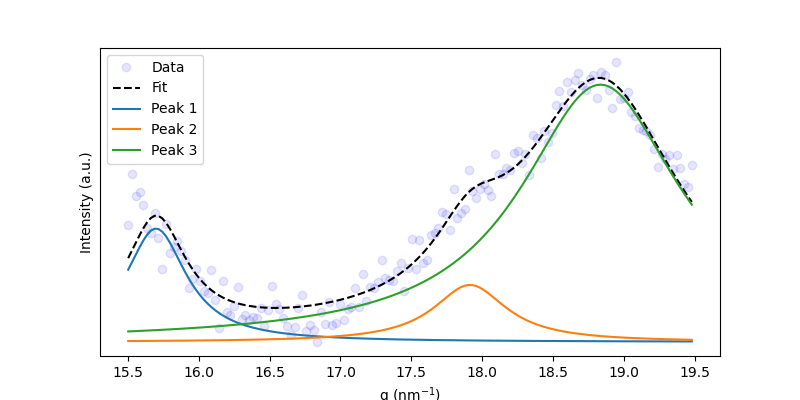

In [23]:
# filter data between ranges

min_x = 15.5
max_x = 19.5

X_positions = corrected_waxs_files[waxs_file_names[starting_file]].iloc[:,0]

indices_within_range = np.where((X_positions >= min_x) & (X_positions <= max_x))

start_row = np.min(indices_within_range)
end_row = np.max(indices_within_range)

# new list with the filtered data 

x_filtered = []
y_filtered = [] 

for entry in range(start_row, end_row+1):
    x_temp = corrected_waxs_files[waxs_file_names[1]].iloc[entry,0]
    y_temp = corrected_waxs_files[waxs_file_names[401]].iloc[entry,1]
    x_filtered.append(x_temp)
    y_filtered.append(y_temp)

x_filtered = np.array(x_filtered)
y_filtered = np.array(y_filtered)

# mean_positions = [18.5, 19.1, 19.5, 19.9, 20.8]
# mean_positions = [18.6, 19.13, 19.9, 20.8]
mean_positions = [15.9,18,18.7]
# mean_positions = [18,18.7]

initial_guess = []

for pos in mean_positions:
    initial_guess += [0.001, pos, 0.1]
# Add baseline to initial guess
initial_guess += [np.min(y_filtered)]

lower_bounds = []
upper_bounds = []

for pos in mean_positions:
    lower_bounds += [0, pos - 0.2, 0]  # Lower bound for [amplitude, center, width]
    upper_bounds += [np.inf, pos + 0.2, 1.0]  # Upper bound for [amplitude, center, width]

# Add bounds for baseline
lower_bounds += [np.min(y_filtered)]
upper_bounds += [0.1]

bounds = (lower_bounds, upper_bounds)

popt_lorentz, pcov_lorentz = curve_fit(
    multi_lorentzian, xdata=x_filtered, ydata=y_filtered, 
    p0=initial_guess, bounds=bounds, max_nfev=100000
)

# Calculate errors from covariance matrix
perr_lorentzian = np.sqrt(np.diag(pcov_lorentz))

num_peaks = len(mean_positions)

for i in range(num_peaks):
    print(f"Peak {i + 1}:")
    print(f" Amplitude = {popt_lorentz[3 * i]+ popt_lorentz[-1]:.4f} +/- {perr_lorentzian[3 * i]:.4f}")
    print(f" Center = {popt_lorentz[3 * i + 1]:.2f} +/- {perr_lorentzian[3 * i + 1]:.4f}")
    print(f" Width = {popt_lorentz[3 * i + 2]:.4f} +/- {perr_lorentzian[3 * i + 2]:.4f}")
    print(f" Area = {(popt_lorentz[3 * i]-popt_lorentz[-1])*popt_lorentz[3 * i + 2]*np.pi:.4f} ")

plt.figure(figsize=(8, 4))
plt.plot(x_filtered, y_filtered, 'bo', label='Data', alpha = 0.1)

plt.plot(x_filtered, multi_lorentzian(x_filtered, *popt_lorentz), 'k--', label='Fit')

for j in range(num_peaks):
    peak_fit = lorentzian(x_filtered, popt_lorentz[3 * j], popt_lorentz[3 * j + 1], popt_lorentz[3 * j + 2]) + popt_lorentz[-1]
    plt.plot(x_filtered, peak_fit, label=f'Peak {j + 1}')

plt.xlabel("q (nm$^{-1}$)")
plt.yticks([])
plt.ylabel("Intensity (a.u.)")
plt.legend()


# Automated fitting over the entire specified range of data

In [24]:
min_x = 15.5
max_x = 19.3

# Filter data between ranges
print(f"Fitting for range {min_x} to {max_x}")
X_positions = corrected_waxs_files[waxs_file_names[starting_file]].iloc[:,0]

indices_within_range = np.where((X_positions >= min_x) & (X_positions <= max_x))

start_row = np.min(indices_within_range)
end_row = np.max(indices_within_range)

df_curves = pd.DataFrame() # Dataframe to save the fitted peak area and widths 


# Define bounds for amplitude and width Required to keep amplitudes within positive values

# Create new list with the filtered data 
for file_number in range(starting_file, last_file+1):
    #print(file_number)
    x_filtered = []
    y_filtered = [] 

    for entry in range(start_row, end_row+1):
        x_temp = corrected_waxs_files[waxs_file_names[file_number]].iloc[entry,0]
        y_temp = corrected_waxs_files[waxs_file_names[file_number]].iloc[entry,1]
        x_filtered.append(x_temp)
        y_filtered.append(y_temp)

    x_filtered = np.array(x_filtered)
    y_filtered = np.array(y_filtered)
    
    initial_guess = []

    for pos in mean_positions:
        initial_guess += [0.001, pos, 0.1]
    # Add baseline to initial guess
    initial_guess += [np.min(y_filtered)]

    lower_bounds = []
    upper_bounds = []

    for pos in mean_positions:
        lower_bounds += [0, pos - 0.2, 0]  # Lower bound for [amplitude, center, width]
        upper_bounds += [np.inf, pos + 0.2, 2.0]  # Upper bound for [amplitude, center, width]

    # Add bounds for baseline
    lower_bounds += [np.min(y_filtered)]
    upper_bounds += [0.1]

    bounds = (lower_bounds, upper_bounds)

    popt_lorentz, pcov_lorentz = curve_fit(
        multi_lorentzian, xdata=x_filtered, ydata=y_filtered, 
        p0=initial_guess, bounds=bounds, max_nfev=100000
    )

    # Calculate errors from covariance matrix
    perr_lorentzian = np.sqrt(np.diag(pcov_lorentz))

    for i in range(len(mean_positions)):
        curve_metrics = [] 
        amplitude = popt_lorentz[3*i] + popt_lorentz[-1]
        center = popt_lorentz[3*i +1]
        w0 = popt_lorentz[3*i +2]
        area = np.pi*amplitude*w0
        fwhm = 2*w0
        df_curves.loc[file_number, f'Peak_{i+1}_Center'] = center
        df_curves.loc[file_number, f'Peak_{i+1}_Amplitude'] = amplitude
        df_curves.loc[file_number, f'Peak_{i+1}_FWHM'] = fwhm
        df_curves.loc[file_number, f'Peak_{i+1}_Area'] = area

print(len(df_curves))
#print(df_curves.head())

Fitting for range 15.5 to 19.3
333


# Data plotting

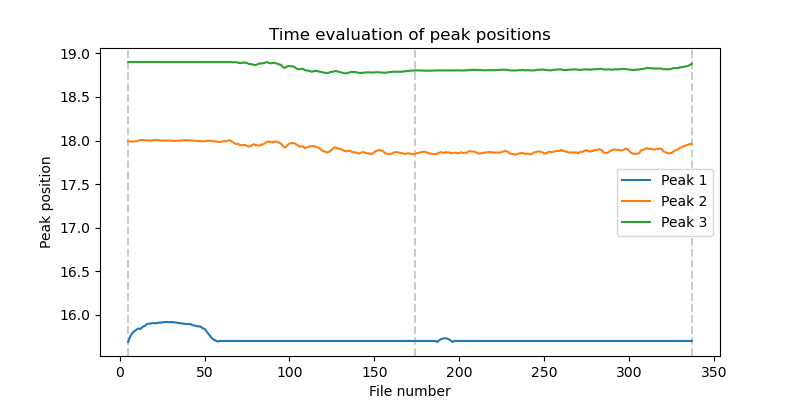

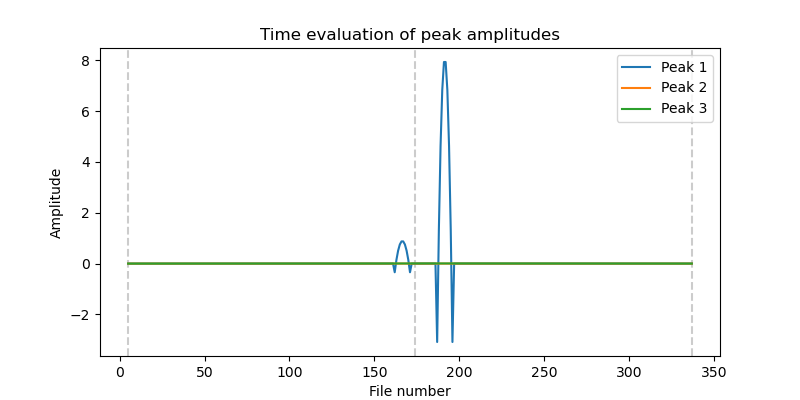

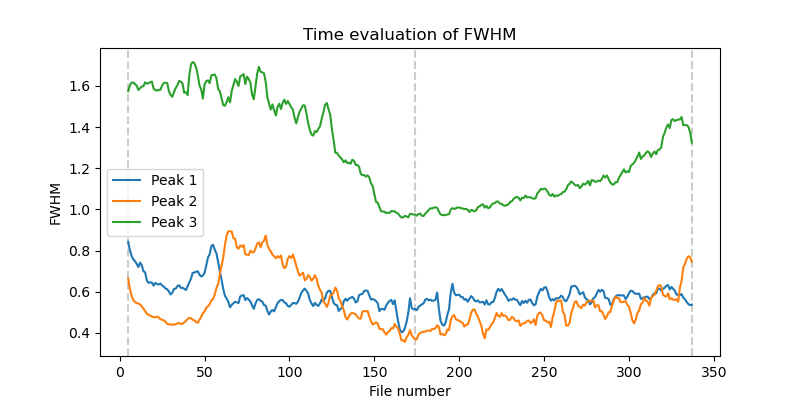

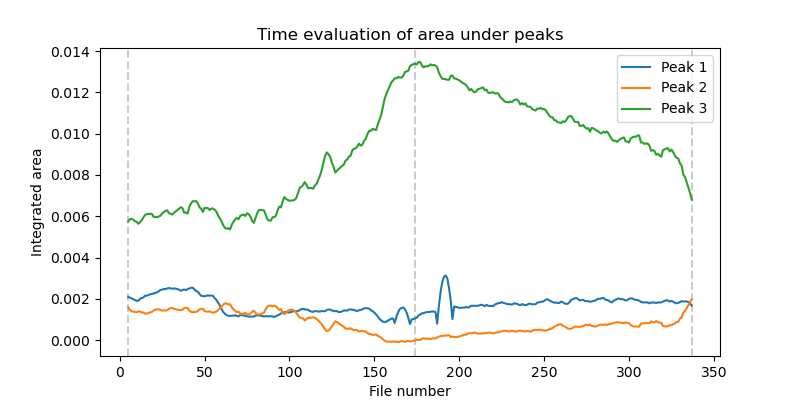

In [25]:
smoothening_window_size = 10
smoothening_poly_order = 3

# Titles and labels for the subplots
titles = [
    "Time evaluation of peak positions",
    "Time evaluation of peak amplitudes",
    "Time evaluation of FWHM",
    "Time evaluation of area under peaks"
]
ylables = ["Peak position", "Amplitude", "FWHM", "Integrated area"]

for plot_no in range(0,4):

    plt.figure(figsize= (8,4))

    for data in saxs_file_numbers:
        plt.axvline(x=data, color='k', linestyle='--', alpha=0.2)
    x1 = df_curves.index

    plt.plot(x1, savgol_filter(df_curves.iloc[:,plot_no], smoothening_window_size, smoothening_poly_order), label = f'Peak 1')
    
    for peak_no in range(1, int(df_curves.shape[1]/4)):
       plt.plot(x1, savgol_filter(df_curves.iloc[:,plot_no+4*peak_no], smoothening_window_size, smoothening_poly_order),label = f'Peak {peak_no +1}')
    
    # Set titles and labels
    plt.title(titles[plot_no])
    plt.xlabel("File number")
    plt.ylabel(ylables[plot_no])
    plt.legend()

# Fitting of individual peaks at specified positions 

In [27]:
df_peak_properties = pd.DataFrame() # Dataframe to save the fitted peak area and widths 

# Place the ranges for the peak fits in the below list 

x_ranges = [(14, 17), (17, 21)] 
peak_count = 0

for min_x, max_x in x_ranges:
    print(f"Fitting peaks in the x range {min_x} to {max_x}")
    temp_df = pd.DataFrame()
    peak_count += 1
    X_positions = corrected_waxs_files[waxs_file_names[starting_file]].iloc[:,0]

    indices_within_range = np.where((X_positions >= min_x) & (X_positions <= max_x))

    start_row = np.min(indices_within_range)
    end_row = np.max(indices_within_range)

    # bounds for amplitude and width Required to keep amplitudes within positive values

    # new list with the filtered data 
    for file_number in range(starting_file, last_file+1):
        #print(file_number)
        x_filtered = []
        y_filtered = [] 
        max_peak_position = 0
        for entry in range(start_row, end_row+1):
            x_temp = corrected_waxs_files[waxs_file_names[file_number]].iloc[entry,0]
            y_temp = corrected_waxs_files[waxs_file_names[file_number]].iloc[entry,1]
            x_filtered.append(x_temp)
            y_filtered.append(y_temp)

        x_filtered = np.array(x_filtered)
        y_filtered = np.array(y_filtered)
        max_peak_position = x_filtered[np.where(y_filtered == y_filtered.max())[0][0]]
     

        guess_center = (min_x + (max_x - min_x)/2)

        initial_guess = [0.001, max_peak_position, 0.1]
        
        initial_guess += [np.min(y_filtered)] # for adding the baseline to the initial guess
        
        lower_bounds = [0, min_x, 0]  # Lower bound for [amplitude, center, width]
        upper_bounds = [np.inf, max_x, 4.0]  # Upper bound for [amplitude, center, width]

        # bounds for baseline
        lower_bounds += [np.min(y_filtered)]
        upper_bounds += [0.01]

        bounds = (lower_bounds, upper_bounds)

        popt_lorentz, pcov_lorentz = curve_fit(
            multi_lorentzian, xdata=x_filtered, ydata=y_filtered, 
            p0=initial_guess, bounds=bounds, max_nfev=200000
        )

        # error calculation from covariance matrix
        perr_lorentzian = np.sqrt(np.diag(pcov_lorentz))

        amplitude = popt_lorentz[0] + popt_lorentz[-1]
        center = popt_lorentz[1]
        w0 = popt_lorentz[2]
        area = np.pi*amplitude*w0
        fwhm = 2*w0

        temp_df.loc[file_number, f'Peak_{peak_count}_Center'] = center
        temp_df.loc[file_number, f'Peak_{peak_count}_Amplitude'] = amplitude
        temp_df.loc[file_number, f'Peak_{peak_count}_FWHM'] = fwhm
        temp_df.loc[file_number, f'Peak_{peak_count}_Area'] = area

    df_peak_properties = pd.concat([df_peak_properties, temp_df], axis=1)
print(len(df_peak_properties))
#print(df_curves.head())

Fitting peaks in the x range 14 to 17
Fitting peaks in the x range 17 to 21
333


# Data plotting

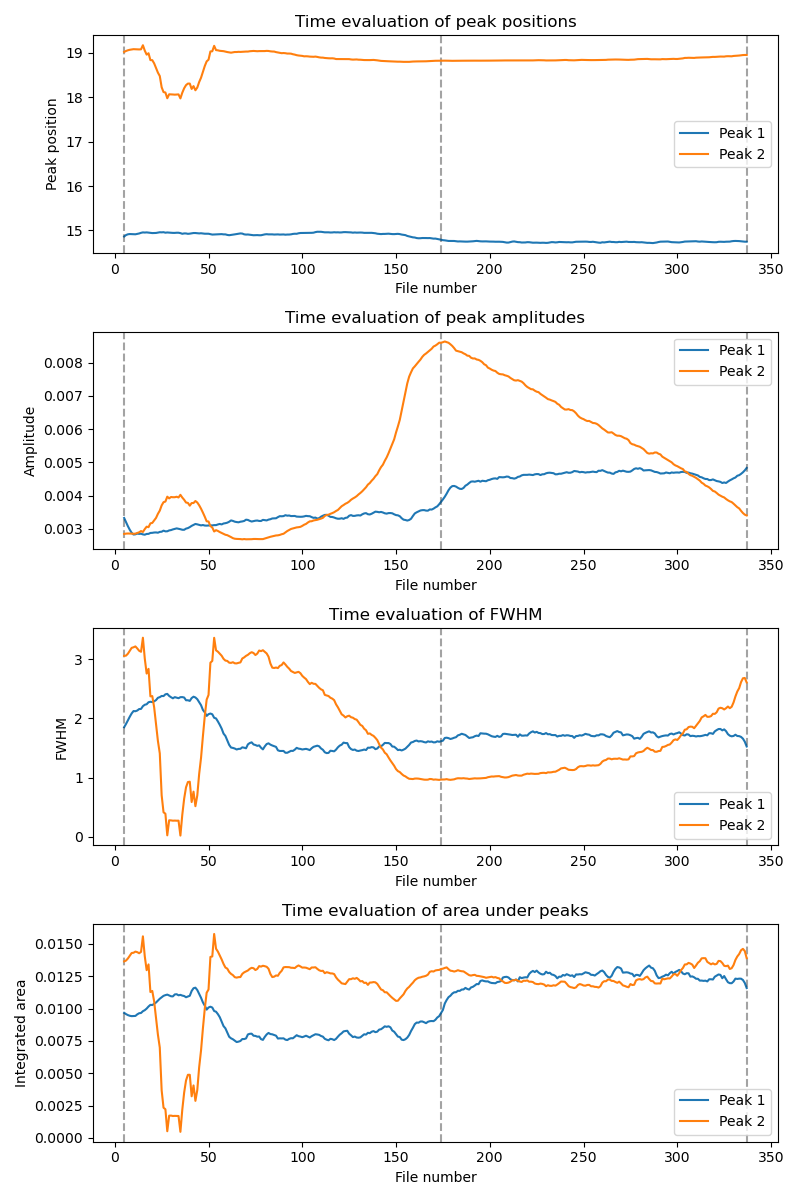

In [28]:
# Plotting via subplots
smoothening_window_size = 10
smoothening_poly_order = 3

# Titles and labels for the subplots
titles = [
    "Time evaluation of peak positions",
    "Time evaluation of peak amplitudes",
    "Time evaluation of FWHM",
    "Time evaluation of area under peaks"
]
ylables = ["Peak position", "Amplitude", "FWHM", "Integrated area"]

# Create a 3x1 subplot
fig, axs = plt.subplots(4, 1, figsize=(8, 12))

# Loop over each peak (assumes two peaks in this case)
for peak_count in range(1, int(df_peak_properties.shape[1]/4)+1):  
    # data for each property from the dataframe (center, FWHM, area)
    x1 = df_peak_properties.index
    y1 = df_peak_properties[f'Peak_{peak_count}_Center']
    y2 = df_peak_properties[f'Peak_{peak_count}_Amplitude']
    y3 = df_peak_properties[f'Peak_{peak_count}_FWHM']
    y4 = df_peak_properties[f'Peak_{peak_count}_Area']

    # Loop through the subplots and plot each property
    for i, ax in enumerate(axs):
       
        for data in saxs_file_numbers:
            ax.axvline(x=data, color='k', linestyle='--', alpha=0.2)

        if i == 0:
            y_data = y1
        elif i == 1:
            y_data = y2
        elif i == 2:
            y_data = y3
        elif i == 3:
            y_data = y4

        # Plot the smoothed data
        ax.plot(x1, savgol_filter(y_data, smoothening_window_size, smoothening_poly_order), label=f'Peak {peak_count}')

        # Set titles and labels
        ax.set_title(titles[i])
        ax.set_xlabel("File number")
        ax.set_ylabel(ylables[i])
        ax.legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


C:\Users\b1104371\AppData\Local\Temp\ipykernel_42576\726453085.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize= (8,4))


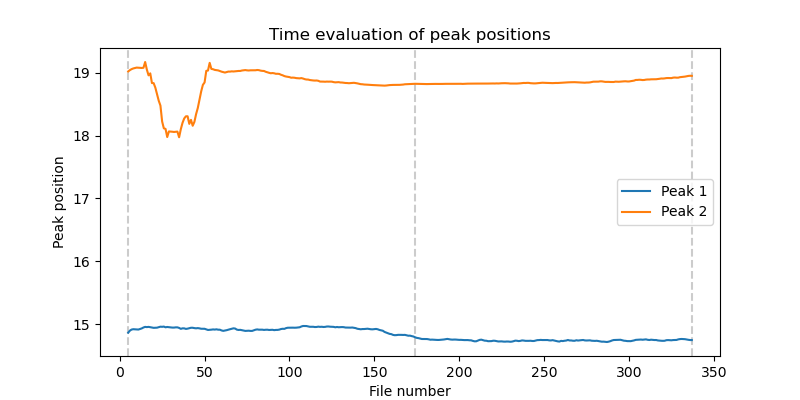

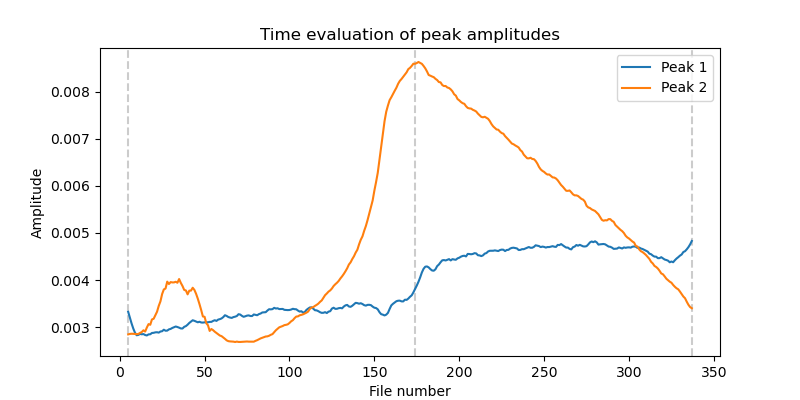

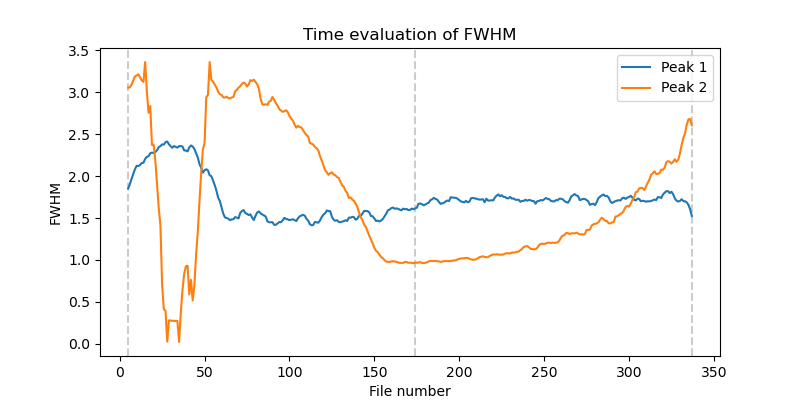

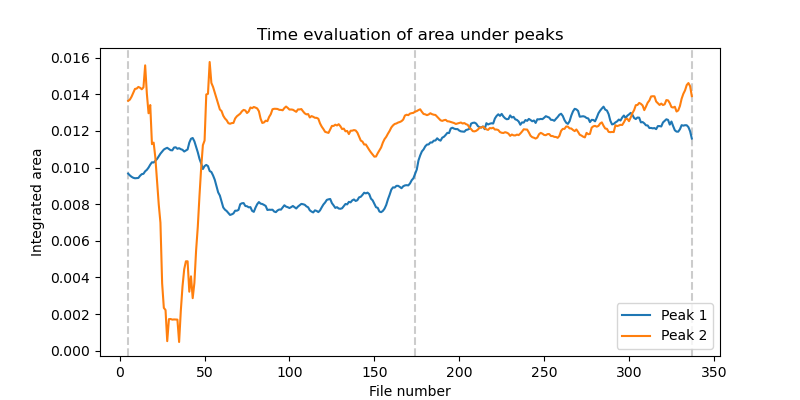

In [29]:
smoothening_window_size = 10
smoothening_poly_order = 3

# Titles and labels for the subplots
titles = [
    "Time evaluation of peak positions",
    "Time evaluation of peak amplitudes",
    "Time evaluation of FWHM",
    "Time evaluation of area under peaks"
]
ylables = ["Peak position", "Amplitude", "FWHM", "Integrated area"]

for plot_no in range(0,4):

    plt.figure(figsize= (8,4))

    for data in saxs_file_numbers:
        plt.axvline(x=data, color='k', linestyle='--', alpha=0.2)
    x1 = df_peak_properties.index

    plt.plot(x1, savgol_filter(df_peak_properties.iloc[:,plot_no], smoothening_window_size, smoothening_poly_order), label = f'Peak 1')
    
    for peak_no in range(1, int(df_peak_properties.shape[1]/4)):
       plt.plot(x1, savgol_filter(df_peak_properties.iloc[:,plot_no+4*peak_no], smoothening_window_size, smoothening_poly_order),label = f'Peak {peak_no +1}')
    
    # Set titles and labels
    plt.title(titles[plot_no])
    plt.xlabel("File number")
    plt.ylabel(ylables[plot_no])
    plt.legend()



In [207]:
print(plt.rcParams['font.family'])

['Arial']


# Create a video file for the automated fitting

In [30]:
import imageio
import os

if not os.path.exists('frames'):
    os.makedirs('frames')
df_curves2 = pd.DataFrame()

min_x = 15.6
max_x = 19

# Filter data between ranges
print(f"Fitting for range {min_x} to {max_x}")
X_positions = corrected_waxs_files[waxs_file_names[starting_file]].iloc[:,0]

indices_within_range = np.where((X_positions >= min_x) & (X_positions <= max_x))

start_row = np.min(indices_within_range)
end_row = np.max(indices_within_range)

# Iterate over all files for peak fitting and saving frames
for file_number in range(starting_file, last_file + 1):
    # Create figure for plotting
    fig, ax = plt.subplots(figsize=(8, 6))

    x_filtered = []
    y_filtered = []

    # Load filtered data for the current file
    for entry in range(start_row, end_row + 1):
        x_temp = corrected_waxs_files[waxs_file_names[file_number]].iloc[entry, 0]
        y_temp = corrected_waxs_files[waxs_file_names[file_number]].iloc[entry, 1]
        x_filtered.append(x_temp)
        y_filtered.append(y_temp)

    x_filtered = np.array(x_filtered)
    y_filtered = np.array(y_filtered)

    # Initial guess and bounds for fitting
    initial_guess = []
    lower_bounds = []
    upper_bounds = []

    for pos in mean_positions:
        initial_guess += [0.001, pos, 0.1]
        lower_bounds += [0, pos - 0.2, 0]
        upper_bounds += [np.inf, pos + 0.2, 1.0]

    # Add baseline to initial guess and bounds
    initial_guess += [np.min(y_filtered)]
    lower_bounds += [np.min(y_filtered)]
    upper_bounds += [0.1]

    bounds = (lower_bounds, upper_bounds)

    # Perform curve fitting
    popt_lorentz, pcov_lorentz = curve_fit(
        multi_lorentzian, xdata=x_filtered, ydata=y_filtered,
        p0=initial_guess, bounds=bounds, max_nfev=100000
    )

    # Calculate errors from covariance matrix
    perr_lorentzian = np.sqrt(np.diag(pcov_lorentz))

    # Plot the raw data
    ax.plot(x_filtered, y_filtered, 'bo', label=f'Raw Data (File {file_number})', alpha = 0.5)

    # Plot the overall fitted Lorentzian curve
    fitted_curve = multi_lorentzian(x_filtered, *popt_lorentz)
    ax.plot(x_filtered, fitted_curve, 'k--', label='Total Fit')

    # Plot individual deconvoluted peaks
    num_peaks = len(mean_positions)
    for j in range(num_peaks):
        peak_fit = lorentzian(x_filtered, popt_lorentz[3 * j], popt_lorentz[3 * j + 1], popt_lorentz[3 * j + 2]) + popt_lorentz[-1]
        ax.plot(x_filtered, peak_fit, label=f'Peak {j + 1}')

        amplitude = popt_lorentz[3 * j] - popt_lorentz[-1]
        center = popt_lorentz[3 * j + 1]
        w0 = popt_lorentz[3 * j + 2]
        df_curves2.loc[file_number, f'Peak_{j + 1}_Center'] = center
        df_curves2.loc[file_number, f'Peak_{j + 1}_FWHM'] = 2 * w0
        df_curves2.loc[file_number, f'Peak_{j + 1}_Area'] = np.pi * amplitude * w0

    # Customize and save plot as a frame
    ax.set_title(f'Fitted Peaks for File {file_number} \n File numbers for elec. change: {saxs_file_numbers}')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.legend()

    frame_path = f'frames/frame_{file_number:03d}.png'
    plt.savefig(frame_path)
    plt.close(fig)  # Close the figure to free memory

# Print completion message for frame generation
print("Frames created successfully!")

# Create a video from the frames
with imageio.get_writer('fitted_plots_video.mp4', fps=2) as writer:
    for file_number in range(starting_file, last_file + 1):
        frame_path = f'frames/frame_{file_number:03d}.png'
        if os.path.exists(frame_path):
            image = imageio.imread(frame_path)
            writer.append_data(image)

# Print completion message for video creation
print("Video saved as fitted_plots_video.mp4")

Fitting for range 15.6 to 19
Frames created successfully!


C:\Users\b1104371\AppData\Local\Temp\ipykernel_42576\144458537.py:102: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame_path)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved as fitted_plots_video.mp4


# Create a video file for the splitted fitting

In [31]:

# Make sure the 'frames' directory exists
if not os.path.exists('frames_individual'):
    os.makedirs('frames_individual')

# Ranges for peak fits
x_ranges = [(14, 17), (17, 21)]
peak_count = 0

# Iterate over files
for file_number in range(starting_file, last_file + 1):
    fig, axes = plt.subplots(1, len(x_ranges), figsize=(16, 6))  # Adjust size based on number of ranges

    # If only one subplot, we need to handle it differently since axes won't be a list
    if len(x_ranges) == 1:
        axes = [axes]
    
    # Iterate over ranges
    for i, (min_x, max_x) in enumerate(x_ranges):
        temp_df = pd.DataFrame()
        peak_count += 1

        X_positions = corrected_waxs_files[waxs_file_names[starting_file]].iloc[:, 0]
        indices_within_range = np.where((X_positions >= min_x) & (X_positions <= max_x))

        start_row = np.min(indices_within_range)
        end_row = np.max(indices_within_range)

        # Filter data for the current range
        x_filtered = []
        y_filtered = []

        for entry in range(start_row, end_row + 1):
            x_temp = corrected_waxs_files[waxs_file_names[file_number]].iloc[entry, 0]
            y_temp = corrected_waxs_files[waxs_file_names[file_number]].iloc[entry, 1]
            x_filtered.append(x_temp)
            y_filtered.append(y_temp)

        x_filtered = np.array(x_filtered)
        y_filtered = np.array(y_filtered)

        # Finding the peak 
        max_peak_position = x_filtered[np.where(y_filtered == y_filtered.max())[0][0]]
        

        # Initial guess for fitting
        # guess_center = (min_x + (max_x - min_x) / 2)

        initial_guess = [0.001, max_peak_position, 0.1]
        # initial_guess = [0.001, guess_center, 0.1]
        initial_guess += [np.min(y_filtered)]  # Adding baseline

        lower_bounds = [0, min_x, 0]  # Amplitude, center, width
        upper_bounds = [np.inf, max_x, 5.0]

        # lower_bounds = [0, guess_center - 0.2, 0]  # Amplitude, center, width
        # upper_bounds = [np.inf, guess_center + 0.2, 2.0]


        lower_bounds += [np.min(y_filtered)]
        upper_bounds += [0.01]

        bounds = (lower_bounds, upper_bounds)

        # Perform fitting
        popt_lorentz, pcov_lorentz = curve_fit(
            multi_lorentzian, xdata=x_filtered, ydata=y_filtered, 
            p0=initial_guess, bounds=bounds, max_nfev=100000
        )

        # Calculate error
        perr_lorentzian = np.sqrt(np.diag(pcov_lorentz))

        # Extract peak properties
        amplitude = popt_lorentz[0] + popt_lorentz[-1]
        center = popt_lorentz[1]
        w0 = popt_lorentz[2]
        area = np.pi * amplitude * w0
        fwhm = 2 * w0

        # Plot data and fit for the current range
        axes[i].plot(x_filtered, y_filtered, 'bo', label=f'Raw Data (Range {i + 1})', alpha=0.5)
        fitted_curve = multi_lorentzian(x_filtered, *popt_lorentz)
        axes[i].plot(x_filtered, fitted_curve, 'r--', label='Fitted Curve')

        # Customize subplot
        axes[i].set_title(f'File {file_number} - Range {min_x}-{max_x}')
        axes[i].set_xlabel('X-axis')
        axes[i].set_ylabel('Y-axis')
        axes[i].legend()

    # Save the plot for this file as a single frame
    frame_path = f'frames_individual/frame_{file_number:03d}.png'
    plt.savefig(frame_path)
    plt.close(fig)  # Close figure to free memory


# Print completion message for frame generation
print("Frames created successfully!")

# Create a video from the frames
with imageio.get_writer('fitted_individual_plots_video.mp4', fps=2) as writer:
    for file_number in range(starting_file, last_file + 1):
        frame_path = f'frames_individual/frame_{file_number:03d}.png'
        if os.path.exists(frame_path):
            image = imageio.imread(frame_path)
            writer.append_data(image)

# Print completion message for video creation
print("Video saved as fitted_individual_plots_video.mp4")


C:\Users\b1104371\AppData\Local\Temp\ipykernel_42576\4053599313.py:105: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame_path)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1600, 600) to (1600, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Frames created successfully!
Video saved as fitted_individual_plots_video.mp4
